# Fire susceptibility probability map — Random Forest (v4, 7–15 km annulus, ratio 1:1)

Applies the winning model (see `outputs/shap/shap_v2_rf_v4.ipynb`) to **every pixel** of
the study nucleus (5 municipalities, Sabanas del Yarí–Bajo Caguán) instead of just the
sampled pixel-year table, so the result can be loaded into ArcGIS and reclassified into
susceptibility levels (low → high).

## Model
- **Algorithm:** Random Forest, hyperparameters from `tuning/v4/v4_buffer_7_15km/v4_best_hyperparameters.csv`.
- **Training data:** the v4 1:1 annulus (7–15 km) dataset, rebuilt from `data/model_dataset/pixel_year_full.csv`
  with the exact same seed/logic used in `shap_v2_rf_v4.ipynb`, so this is the **same final
  model** already validated and interpreted with SHAP — fit on the **full** dataset (all
  years, train+test combined), not just the pre-2020 training split.

## Predictor conditions for the pixel grid
Of the 9 predictors, 4 are already static/current in the training pipeline (they don't
vary by year): `dist_roads`, `dist_parks`, `dist_coca`, `dist_mosaic`. The other 5 vary by
year: `temp_C`, `vpd_kPa`, `ndvi`, `wind_ms`, `oni`.

This map represents **climatological-normal / baseline susceptibility**, not a forecast
for a specific year (consistent with the "susceptibility, not forecast" framing in
`WORKFLOW.md`):
- `temp_C`, `vpd_kPa`, `ndvi`, `wind_ms` → per-pixel **mean of the 2001–2024 dry-season
  images** (same dry-season definition used in training: Dec(y-1)–Feb(y)).
- `oni` → **0** (ENSO-neutral), so the map isn't biased toward any particular El Niño/La
  Niña state.
- Anthropogenic distance layers use the **current** state already baked into the training
  pipeline (2024 MapBiomas classification for `dist_mosaic`, cumulative coca ever grown
  through 2023 for `dist_coca`, current roads/parks assets).

## Coverage caveat: `dist_roads` / `dist_coca` extrapolation
Training capped `dist_roads`/`dist_coca` at a 10 km search radius purely to keep the ~8,000-point
GEE sample cheap — points farther than 10 km came back masked and were dropped via `.dropna()`
when `pixel_year_full.csv` was built, so **the model never saw `dist_roads`/`dist_coca` values
above 10 km**. This notebook widens that radius to 100 km for the full-region export (matching
`dist_parks`, which already used 100 km and covers the whole nucleus with no gaps) so every pixel
gets a prediction. Predictions in pixels beyond ~10 km from any road/coca field are therefore a
model **extrapolation**, not an interpolation — interpret the map's deep-forest, low-accessibility
areas with that caveat in mind.

## Outputs (this folder)
- `rf_v4_final.joblib` — the fitted Random Forest (for reuse without retraining).
- `predictor_stack_v4.tif` — intermediate 9-band GeoTIFF (the exported covariate grid).
- `fire_susceptibility_probability_v4.tif` — **the deliverable**: single-band float32
  GeoTIFF, pixel value = predicted probability of burning (0–1), EPSG:4326, ~500 m
  resolution, ready to load into ArcGIS.
- `quicklook_probability_map.png` — quick sanity-check preview.


In [1]:
# === Setup ===
# This notebook lives in 'outputs/probability_map/' (two levels below repo root, same depth as outputs/shap/).
import os, sys
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import ee
import geemap
import rasterio
import joblib

import col_amazon_fire_utils as utils

ee = utils.initialize_ee()
nucleus_geom = utils.get_nucleus_geometry()

OUT_DIR = Path(r"C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\outputs\probability_map")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PIXEL_YEAR_PATH = Path(r"C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\data\model_dataset\pixel_year_full.csv")
V4_HP_PATH = Path(r"C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\tuning\v4\v4_buffer_7_15km\v4_best_hyperparameters.csv")

pred_cols = ['dist_roads','dist_parks','dist_coca','dist_mosaic',
             'temp_C','vpd_kPa','ndvi','wind_ms','oni']

print("Output folder:", OUT_DIR)
print("EE + nucleus geometry ready.")

Output folder: C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\probability map
EE + nucleus geometry ready.


## 1 · Rebuild the v4 dataset and fit the final Random Forest

Identical recipe to `outputs/shap/shap_v2_rf_v4.ipynb`: same seed (42), same 7–15 km
annulus pseudo-absence sampling from `pixel_year_full.csv`, same hyperparameters from
`tuning/v4`, fit on the **full** v4 dataset. This guarantees the deployed model is exactly
the one already validated and explained with SHAP, not a re-derived variant.

In [2]:
# === Rebuild v4 (7-15 km annulus, ratio 1:1) dataset -- same recipe as shap_v2_rf_v4.ipynb ===
import ast
from scipy.spatial import cKDTree
from sklearn.ensemble import RandomForestClassifier

pixel_year = pd.read_csv(PIXEL_YEAR_PATH)

BLOCK = 0.25
INNER_BUFFER = 7000            # v4: inner radius of the annulus
OUTER_BUFFER = 15000           # v4: outer radius of the annulus
inner_deg = INNER_BUFFER / 111000
outer_deg = OUTER_BUFFER / 111000
RATIO = 1                      # winning ratio identified in tuning/v3, kept in v4
SEED = 42

presences = pixel_year[pixel_year['burned'] == 1].copy()
absences_all = pixel_year[pixel_year['burned'] == 0].copy()

kept_absences = []
for y in sorted(pixel_year['year'].unique()):
    pres_y = presences[presences['year'] == y][['lon','lat']].values
    abs_y  = absences_all[absences_all['year'] == y]
    if len(pres_y) == 0:
        kept_absences.append(abs_y); continue
    tree = cKDTree(pres_y)
    dists, _ = tree.query(abs_y[['lon','lat']].values, k=1)
    in_ring = (dists >= inner_deg) & (dists <= outer_deg)
    kept_absences.append(abs_y[in_ring])
absences_ring = pd.concat(kept_absences, ignore_index=True)

n_needed = int(round(RATIO * len(presences)))
print(f"Annulus {INNER_BUFFER/1000:.0f}-{OUTER_BUFFER/1000:.0f} km | "
      f"eligible: {len(absences_ring):,} | needed: {n_needed:,}")
if len(absences_ring) < n_needed:
    print(f"  WARNING: pool too small, missing {n_needed - len(absences_ring):,} pseudo-absences.")

# Stratified sampling by year, mirroring the annual weight of presences (same as v4)
absences_sample = (absences_ring.groupby('year', group_keys=False)
                   .apply(lambda g: g.sample(
                       n=min(len(g), int((presences['year'] == g.name).sum() * RATIO)),
                       random_state=SEED)))

model_df = pd.concat([presences, absences_sample], ignore_index=True) \
             .sample(frac=1, random_state=SEED).reset_index(drop=True)

n_pres = int(model_df['burned'].sum())
print(f"Dataset v4 (annulus 7-15 km, ratio {RATIO}:1) ->", model_df.shape, f"({n_pres} presences)")

# --- Winning RF hyperparameters from tuning/v4 ---
RF_PARAMS = {'n_estimators': 500, 'max_features': 0.5, 'min_samples_leaf': 5, 'max_depth': None}

def _parse_param(v):
    if pd.isna(v):
        return None
    if isinstance(v, (int, np.integer)):
        return int(v)
    if isinstance(v, (float, np.floating)):
        return int(v) if v.is_integer() else float(v)
    s = str(v)
    if s == "None":
        return None
    try:
        return ast.literal_eval(s)
    except Exception:
        return s

v4_hp = pd.read_csv(V4_HP_PATH)
rf_row = v4_hp[v4_hp['model'] == 'Random Forest']
if len(rf_row):
    RF_PARAMS = {c: _parse_param(rf_row.iloc[0][c]) for c in v4_hp.columns
                 if c != 'model' and pd.notna(rf_row.iloc[0][c])}
print("RF hyperparameters (tuning/v4):", RF_PARAMS)

X_df = model_df[pred_cols].copy()
X = X_df.values
y = model_df['burned'].astype(int).values
rf = RandomForestClassifier(random_state=SEED, n_jobs=-1, **RF_PARAMS)
rf.fit(X, y)
print("Final RF (v4) trained on", X.shape[0], "rows.")

joblib.dump(rf, OUT_DIR / "rf_v4_final.joblib")
print("Saved:", OUT_DIR / "rf_v4_final.joblib")

Annulus 7-15 km | eligible: 14,928 | needed: 2,077
Dataset v4 (annulus 7-15 km, ratio 1:1) -> (4154, 13) (2077 presences)
RF hyperparameters (tuning/v4): {'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 500}


Final RF (v4) trained on 4154 rows.


Saved: C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\probability map\rf_v4_final.joblib


## 2 · Build the 9-band predictor image for the whole study nucleus

### 2a — Static anthropogenic distance layers
Same layers/logic as `model/logistic_regression/baseline_comparison.ipynb` (roads, parks,
coca, agricultural-frontier mosaic distance), with **one deliberate change**: training used
a 10 km search radius on `dist_roads`/`dist_coca` purely as a GEE computation cap when
drawing ~8,000 sample points (any point farther than 10 km came back masked and was dropped
via `.dropna()` when `pixel_year_full.csv` was built). For a full-region raster that cap
would leave large nodata holes *inside* the nucleus wherever a pixel is >10 km from both a
road and any historical coca polygon. `dist_parks` already uses a 100 km radius in the
original code and empirically covers the whole nucleus with zero extra masking (Colombia's
road/coca network is denser than its park network), so we use that same 100 km radius for
all three distance layers here — it's just computing the real Euclidean distance everywhere
instead of capping it for sampling efficiency. Caveat: the model was never trained on
`dist_roads`/`dist_coca` values above 10 km, so predictions in pixels beyond that range
(deep-forest, far from any road or coca field) are an extrapolation beyond the training
sample's feature range, not an interpolation.

In [3]:
# === Static anthropogenic distance predictors (roads/coca/mosaic use baseline_comparison.ipynb's
# logic; radius widened to 100 km -- see markdown above -- so the full nucleus gets a value) ===
MAP_SEARCH_RADIUS = 100000   # 100 km: matches dist_parks' original radius, empirically covers the nucleus

mb_lulc = ee.Image('projects/mapbiomas-colombia/assets/LULC/COLECCION3/INTEGRACION/COLOMBIA-1')
from_codes = [3, 6, 5,   4, 11, 12, 13,   15,   18, 35,   21,   33,   9, 23, 24, 29, 30, 68]
to_groups  = [1, 1, 1,   2,  2,  2,  2,    3,    4,  4,    5,    6,    7,  7,  7,  7,  7,  7]

base = 'projects/col-amazon-fire-susceptibility/assets/'
layers = {
    'parks': ee.FeatureCollection(base + 'national_natural_parks'),
    'roads': ee.FeatureCollection(base + 'osm_roads_v2'),
    'coca':  ee.FeatureCollection(base + 'coca_cultivation_v2'),
}

buf = nucleus_geom.buffer(MAP_SEARCH_RADIUS)

dist_roads = layers['roads'].filterBounds(buf).distance(MAP_SEARCH_RADIUS).rename('dist_roads')
dist_parks = layers['parks'].filterBounds(buf).distance(MAP_SEARCH_RADIUS).rename('dist_parks')

def coca_ever(f):
    total = ee.List([ee.Number(f.get(f'coca_{y}')) for y in range(2001, 2024)]).reduce(ee.Reducer.sum())
    return f.set('coca_total', total)
coca_any = layers['coca'].filterBounds(buf).map(coca_ever).filter(ee.Filter.gt('coca_total', 0))
dist_coca = coca_any.distance(MAP_SEARCH_RADIUS).rename('dist_coca')

mosaic_mask = mb_lulc.select('classification_2024').clip(buf).remap(from_codes, to_groups, 0).eq(5)
dist_mosaic = (mosaic_mask.selfMask().fastDistanceTransform().sqrt()
               .multiply(ee.Image.pixelArea().sqrt()).rename('dist_mosaic'))

dist_stack = dist_roads.addBands(dist_parks).addBands(dist_coca).addBands(dist_mosaic)
print("Static distance predictors ready:", dist_stack.bandNames().getInfo())

Static distance predictors ready: ['dist_roads', 'dist_parks', 'dist_coca', 'dist_mosaic']


### 2b — Climatological-normal dry-season climate (2001–2024 per-pixel mean) + ENSO-neutral `oni`

Same `climate_year()` definition used to build `pixel_year_full.csv`, run for every year
2001–2024 and averaged band-by-band **per pixel** (not collapsed to one scalar), so the
natural spatial gradient in temperature/VPD/NDVI/wind across the nucleus is preserved.

In [4]:
# === Climatological-normal dry-season climate stack (per-pixel mean, 2001-2024) ===
def climate_year(year):
    """Dry-season (Dec[y-1]-Feb[y]) climate image for ONE year -- temp, vpd, ndvi, wind."""
    start = ee.Date.fromYMD(year - 1, 12, 1); end = ee.Date.fromYMD(year, 3, 1)
    era5 = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR').filterDate(start, end)
    def derive(img):
        u = img.select('u_component_of_wind_10m'); v = img.select('v_component_of_wind_10m')
        wind = u.hypot(v).rename('wind_ms')
        t = img.select('temperature_2m').subtract(273.15)
        td = img.select('dewpoint_temperature_2m').subtract(273.15)
        es = t.expression('0.6108*exp(17.27*T/(T+237.3))', {'T': t})
        e = td.expression('0.6108*exp(17.27*Td/(Td+237.3))', {'Td': td})
        return img.addBands([wind, es.subtract(e).rename('vpd_kPa')])
    era5 = era5.map(derive)
    temp = era5.select('temperature_2m').mean().subtract(273.15).rename('temp_C')
    vpd  = era5.select('vpd_kPa').mean()
    wind = era5.select('wind_ms').mean()
    ndvi = (ee.ImageCollection('MODIS/061/MOD13A1').filterDate(start, end)
            .select('NDVI').mean().multiply(0.0001).rename('ndvi'))
    return temp.addBands([vpd, ndvi, wind])

yearly_climate = ee.ImageCollection([climate_year(y) for y in range(2001, 2025)])
climate_normal = yearly_climate.mean()   # per-pixel 2001-2024 dry-season mean

oni_neutral = ee.Image.constant(0).rename('oni').toFloat()

print("Climatological-normal climate bands:", climate_normal.bandNames().getInfo())

Climatological-normal climate bands: ['temp_C', 'vpd_kPa', 'ndvi', 'wind_ms']


### 2c — Combine into the 9-band predictor stack (band order must match `pred_cols`)

In [5]:
# === Assemble the 9-band image in the exact pred_cols order, clip to the nucleus ===
predictor_image = (dist_stack
                    .addBands(climate_normal)
                    .addBands(oni_neutral)
                    .select(pred_cols)          # enforce order == pred_cols
                    .toFloat()
                    .clip(nucleus_geom)
                    .unmask(-9999, False))      # sameFootprint=False: extend -9999 to the WHOLE export
                                                 # rectangle, not just gaps inside the clipped footprint --
                                                 # otherwise pixels outside the polygon (but inside the bbox)
                                                 # stay masked and the raw pixel-fetch silently writes 0.

band_names = predictor_image.bandNames().getInfo()
assert band_names == pred_cols, f"Band order mismatch: {band_names} != {pred_cols}"
print("Predictor stack ready, band order verified:", band_names)

Predictor stack ready, band order verified: ['dist_roads', 'dist_parks', 'dist_coca', 'dist_mosaic', 'temp_C', 'vpd_kPa', 'ndvi', 'wind_ms', 'oni']


## 3 · Export the predictor stack to a local GeoTIFF

~112,290 km² at 500 m ≈ 450k pixels × 9 float32 bands ≈ 16 MB — small enough for a direct
download via `geemap` (no Drive export needed). CRS is EPSG:4326 to match the `lon`/`lat`
coordinates the model was trained on; scale=500 m matches the sampling scale used to build
`pixel_year_full.csv`.

In [6]:
STACK_TIF = OUT_DIR / "predictor_stack_v4.tif"

geemap.ee_export_image(
    predictor_image,
    filename=str(STACK_TIF),
    scale=500,
    crs='EPSG:4326',
    region=nucleus_geom,
    file_per_band=False,
)
print("Saved:", STACK_TIF)

Generating URL ...


Please wait ...


Data downloaded to C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\probability map\predictor_stack_v4.tif
Saved: C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\probability map\predictor_stack_v4.tif


## 4 · Predict fire-susceptibility probability for every pixel

Runs the fitted `rf` (identical model used in the SHAP analysis) on every valid pixel of
the exported stack and writes a single-band probability GeoTIFF. Pixels outside the
nucleus (or with a gap in any predictor) keep the `-9999` nodata sentinel.

In [7]:
NODATA = -9999.0
PROB_TIF = OUT_DIR / "fire_susceptibility_probability_v4.tif"

with rasterio.open(STACK_TIF) as src:
    profile = src.profile.copy()
    stack = src.read()   # shape: (9, H, W), band order == pred_cols (see section 2c)
    assert stack.shape[0] == len(pred_cols), \
        f"Expected {len(pred_cols)} bands, got {stack.shape[0]}"

n_bands, H, W = stack.shape
flat = stack.reshape(n_bands, -1).T   # (H*W, 9)

valid = ~np.any((flat == NODATA) | np.isnan(flat), axis=1)
print(f"Valid pixels: {valid.sum():,} / {flat.shape[0]:,} ({100*valid.mean():.1f}%)")

proba = np.full(flat.shape[0], NODATA, dtype=np.float32)
proba[valid] = rf.predict_proba(flat[valid])[:, 1].astype(np.float32)
proba_grid = proba.reshape(H, W)

profile.update(count=1, dtype='float32', nodata=NODATA)
with rasterio.open(PROB_TIF, 'w', **profile) as dst:
    dst.write(proba_grid, 1)
    dst.set_band_description(1, 'fire_susceptibility_probability')

print("Saved:", PROB_TIF)
valid_vals = proba_grid[proba_grid != NODATA]
print(f"Probability range: [{valid_vals.min():.3f}, {valid_vals.max():.3f}] | mean: {valid_vals.mean():.3f}")

Valid pixels: 453,916 / 936,936 (48.4%)


Saved: C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\probability map\fire_susceptibility_probability_v4.tif
Probability range: [0.006, 0.948] | mean: 0.204


## 5 · Quick-look preview (sanity check before opening in ArcGIS)

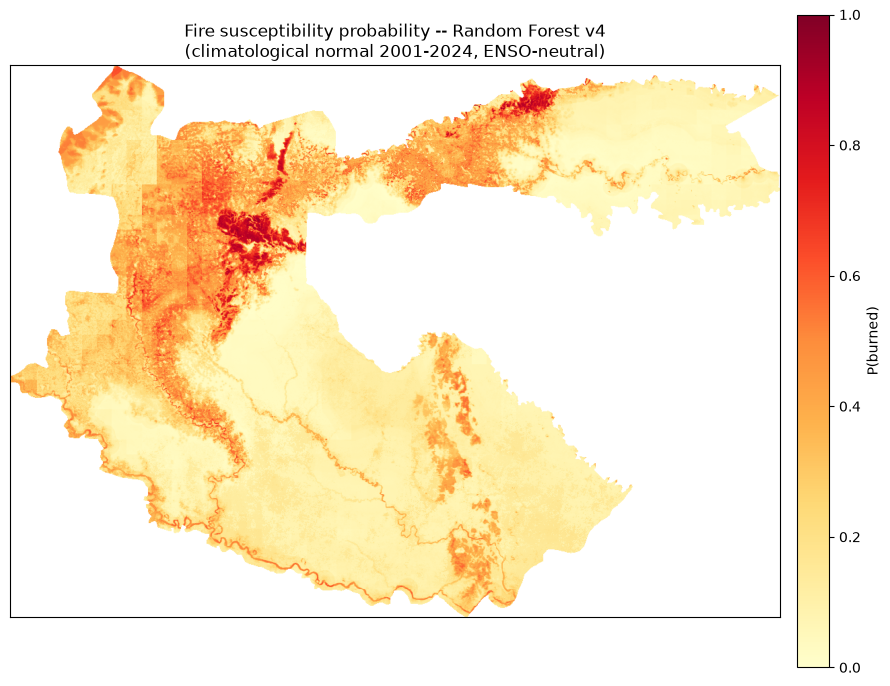

Saved: C:\Users\Natal\CEGE0049-Wildfire-Susceptibility-Assessment-in-Sabanas-de-Yar---Bajo-Cagu-n-Colombian-Amazon\probability map\quicklook_probability_map.png

Probability distribution (valid pixels):
count    453916.000000
mean          0.204461
std           0.170533
min           0.005671
25%           0.078333
50%           0.140244
75%           0.311280
max           0.948044
dtype: float64


In [8]:
display_grid = np.ma.masked_equal(proba_grid, NODATA)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(display_grid, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_title('Fire susceptibility probability -- Random Forest v4\n(climatological normal 2001-2024, ENSO-neutral)')
ax.set_xticks([]); ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('P(burned)')
plt.tight_layout()
plt.savefig(OUT_DIR / "quicklook_probability_map.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved:", OUT_DIR / "quicklook_probability_map.png")

print("\nProbability distribution (valid pixels):")
print(pd.Series(valid_vals).describe())

## 6 · Using this in ArcGIS

Load `fire_susceptibility_probability_v4.tif` (nodata = -9999, EPSG:4326, ~500 m). It's a
continuous probability surface (0–1) — to turn it into discrete susceptibility levels
(Muy bajo → Muy alto), symbolize with a **Classified** renderer using **Natural Breaks
(Jenks)** with 5 classes (`Symbology → Classify → Jenks`), or run the classification in
Python first if you want the class breaks recorded in the repo.

## Next steps (from `WORKFLOW.md`'s roadmap)
1. **Jenks classification** — convert this probability raster into 5 discrete susceptibility
   classes (item 3 in `WORKFLOW.md`).
2. **Socio-ecological exposure & carbon at risk** — overlay the classified map with land
   cover, parks, and forest carbon layers (item 5 in `WORKFLOW.md`).
